# Train model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import tqdm

from load_qm9 import *

#load dataset
ds = qm9_load_torch()

device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

ATOM_TYPES = [1, 6, 7, 8, 9]
MAX_SIZE = 30 # max number of atoms per molecules


Using device: cpu


### one hot encoding for the molecule shape

In [4]:
def one_hot_encode(batch):
    x = batch[0]
    x -= torch.mean(x, axis=1)[:, None, :]
    e = batch[1]
    q = batch[2]
    
    max_atom_type = max(ATOM_TYPES) + 1
    lookup = torch.full((max_atom_type,), -1, dtype=torch.long)
    
    for idx, atom_type in enumerate(ATOM_TYPES):
        lookup[atom_type] = idx
    
    y_indices = lookup[e]
    
    assert (y_indices >= 0).all(), "Types d'atomes inconnus détectés!"
    
    
    e = torch.nn.functional.one_hot(y_indices, num_classes=len(ATOM_TYPES)).float()
    
    return [x, e, q]

def one_hot_decode(batch):
    x = batch[0].clone().detach()
    e_onehot = batch[1].clone().detach()
    q = batch[2].clone().detach()
    
    e_indices = torch.argmax(e_onehot, dim=-1)  # (batch_size, n_atoms)
    atom_types_tensor = torch.tensor(ATOM_TYPES, dtype=torch.long)
    e = atom_types_tensor[e_indices]
    
    return [x, e, q]



def one_hot_decode_stochastic(batch, temperature=1.0):
    x = batch[0].clone().detach()
    e_soft = batch[1].clone().detach()
    q = batch[2].clone().detach()
    
    # Option 2: Sampling selon les probabilités (stochastic)
    e_probs = torch.nn.functional.softmax(e_soft / temperature, dim=-1)
    e_indices = torch.multinomial(
        e_probs.view(-1, e_probs.size(-1)), 
        num_samples=1
    ).view(e_probs.shape[:-1])
    
    atom_types_tensor = torch.tensor(ATOM_TYPES, dtype=torch.long)
    e = atom_types_tensor[e_indices]
    
    return [x, e, q]

## Model

In [10]:
class UltraMagaDiffusion(torch.nn.Module):
    def __init__(self):
        super(UltraMagaDiffusion, self).__init__()
        self.T = 1000
        s = 1e-5
        # regularization on alpha from the paper
        alpha_unstable = [(1-2*s)*(1 - (t/self.T)**2)+s for t in range(self.T+1)]
        alpha_unstable = torch.tensor(alpha_unstable, device=device)
        alpha_unstable_shift = torch.cat([torch.tensor([1.0], device=device), alpha_unstable[:-1]])
        alpha_ts_unstable = alpha_unstable / alpha_unstable_shift
        alpha_ts_sq_clipped = torch.clamp(alpha_ts_unstable**2, min=0.001)
        alpha_ts_stable = torch.sqrt(alpha_ts_sq_clipped)
        self.alpha = torch.cumprod(alpha_ts_stable, dim=0)

        self.omega = (1.0 - self.alpha**2).clamp(min=1e-8)
        self.L = 9
        self.nf = 256
        self.lr = 1e-4
        self.num_class = len(ATOM_TYPES)

        self.init_weight()
    
    def init_weight(self):
        self.phi_e = torch.nn.ModuleList()
        self.phi_inf = torch.nn.ModuleList()
        self.phi_x = torch.nn.ModuleList()
        self.phi_h = torch.nn.ModuleList()

        nf_in_features = self.num_class + 1 # 5 (one-hot) + 1 (charge)
        nf_in = nf_in_features + 1 # +1 pour le temps
        
        
        self.h_embed = torch.nn.Linear(nf_in, self.nf) # Projeter l'entrée (7) vers la dimension cachée (256)
        
        for l in range(self.L):
            # phi_e
            self.phi_e.append(torch.nn.Sequential(
                torch.nn.Linear(self.nf * 2 + 2, self.nf), # 256*2+2 -> 256
                torch.nn.SiLU(),
                torch.nn.Linear(self.nf, self.nf),        # 256 -> 256
                torch.nn.SiLU(),
            ))

            # phi_inf 
            self.phi_inf.append(torch.nn.Sequential(
                torch.nn.Linear(self.nf, 1), # 256 -> 1
                torch.nn.Sigmoid(),
            ))

            # phi_x 
            self.phi_x.append(torch.nn.Sequential(
                torch.nn.Linear(self.nf * 2 + 2, self.nf), # 256*2+2 -> 256
                torch.nn.SiLU(),
                torch.nn.Linear(self.nf, self.nf),
                torch.nn.SiLU(),
                torch.nn.Linear(self.nf, 1), # 256 -> 1
            ))

            # phi_h 
            self.phi_h.append(torch.nn.Sequential(
                torch.nn.Linear(self.nf + self.nf, self.nf), # [h_i, m_agg] -> nf
                torch.nn.SiLU(),
                torch.nn.Linear(self.nf, self.nf), # 256 -> 256
            ))
            
        # Projection finale
        self.h_final = torch.nn.Linear(self.nf, nf_in_features) # 256 -> 6


    def forward(self, mols, t):
        (x, e, q) = mols # (x, e_onehot, q)
        
        h_features = torch.cat([e, q[:, :, None]], dim=-1) # (B, N, 6)
        h_time = torch.ones_like(q)[:, :, None] * t[:, :, None] / self.T # (B, N, 1)
        h_in = torch.cat([h_features, h_time], dim=-1) # (B, N, 7)
        
        x0 = x.clone() 
        
        h = self.h_embed(h_in) # (B, N, 256)

        N = h.shape[1]
        diff = x[:, :, None, :] - x[:, None, :, :]
        a_ij = torch.sqrt(torch.sum(diff ** 2, dim=-1))[:, :, :, None]
        
        for l in range(self.L):
            diff = x[:, :, None, :] - x[:, None, :, :]
            d_ij = torch.sqrt(torch.clamp(torch.sum(diff ** 2, dim=-1), min=1e-9))[:, :, :, None]
        
            h_i = h[:, :, None, :].expand(-1, N, N, -1)  # (B, N, N, 256)
            h_j = h[:, None, :, :].expand(-1, N, N, -1)  # (B, N, N, 256)

            features = torch.cat([h_i, h_j, d_ij, a_ij], dim=-1) # (B, N, N, 514)
            m_ij = self.phi_e[l](features)  # (B, N, N, 256)
            e_ij = self.phi_inf[l](m_ij)
            weights = self.phi_x[l](features) * diff / (d_ij + 1.0)
            x = x + weights.sum(dim=2)

            mask = ~torch.eye(N, dtype=bool, device=device)[None, :, :, None]
            agg = (e_ij * mask * m_ij).sum(dim=2)   # (B, N, 256)
            
            # Connexion résiduelle comme dans le papier [cite: 503]
            h = h + self.phi_h[l](torch.cat([h, agg], dim=-1))
    
        eps_x = x - x0
        eps_x = eps_x - torch.mean(eps_x, axis=1)[:, None, :] # Centre le bruit
        
        eps_h_features = self.h_final(h) # (B, N, 6)
        
        # Séparer e et q
        eps_e = eps_h_features[:, :, :self.num_class]
        eps_q = eps_h_features[:, :, self.num_class]
        
        return (eps_x, eps_e, eps_q)
    

    def training_step(self, batch, optimizer):
        self.train()
        optimizer.zero_grad()

        x, e, q = batch
        B = x.shape[0]
        e = e * 0.25  # h_onehot
        q = q * 0.1   # h_atom_charge

        t = torch.randint(1, self.T + 1, (B, 1), device=device).float() # Random timestep per batch
        eps_x = torch.randn_like(x, device=device) # (B, N, 3)
        eps_e = torch.randn_like(e, device=device) # (B, N, D)
        eps_q = torch.randn_like(q, device=device) # (B, N)

        eps_x = eps_x - torch.mean(eps_x, dim=1, keepdim=True)
        

        # Diffusion step: add noise to x0
        alpha_t = self.alpha[t.long()].view(B, 1, 1)
        omega_t = torch.sqrt(self.omega[t.long()].view(B, 1, 1))
        x_t = alpha_t * x + omega_t * eps_x
        e_t = alpha_t * e + omega_t * eps_e
        q_t = alpha_t.squeeze(-1) * q + omega_t.squeeze(-1) * eps_q

        # Predict denoised offset (model learns to predict ε)
        eps_x_pred, eps_e_pred, eps_q_pred = self.forward((x_t, e_t, q_t), t)
        
        # Reconstruction loss (denoising loss)
        loss_x = torch.nn.functional.mse_loss(eps_x_pred, eps_x)
        loss_e = torch.nn.functional.mse_loss(eps_e_pred, eps_e)
        loss_q = torch.nn.functional.mse_loss(eps_q_pred, eps_q)

        loss = loss_x + 0.25*loss_e + 0.1*loss_q 
        loss.backward()
        #print("====3debug :", torch.max(loss))
        optimizer.step()
        #print("====3debug :", torch.max(self.phi_x[0][0].weight))

        return {
            'loss': loss.detach().cpu().item(),
            'loss_x': loss_x.detach().cpu().item(),
            'loss_e': loss_e.detach().cpu().item(),
            'loss_q': loss_q.detach().cpu().item(),
        }


    @torch.no_grad()
    def sample(self, batch_size, N):
        self.eval()

        # Initialize x_T from Gaussian noise
        x = torch.randn(batch_size, N, 3, device=device)
        x = x - torch.mean(x, dim=1, keepdim=True)
        e = torch.randn(batch_size, N, self.num_class, device=device)
        q = torch.randn(batch_size, N, device=device)

        for t in tqdm.tqdm(reversed(range(1, self.T + 1))):
            t_tensor = torch.full((batch_size, 1), t, device=device).float()
            dx, de, dq = self.forward((x, e, q), t_tensor)

            # Compute coefficients
            alpha_t = self.alpha[t].view(1, 1, 1)
            omega_t = self.omega[t].view(1, 1, 1)
            alpha_s = self.alpha[t-1].view(1, 1, 1)
            omega_s = self.omega[t-1].view(1, 1, 1)

            alpha_ts = alpha_t/alpha_s
            omega_ts = omega_t - alpha_ts**2 * omega_s
            omega_t_s = torch.sqrt(omega_ts * omega_s / omega_t)
            # Reverse diffusion step
            if t>1:
                eps_x = torch.randn_like(x, device=device)
                eps_x= eps_x - torch.mean(eps_x, dim=1, keepdim=True)

                eps_e = torch.randn_like(e, device=device)

                eps_q = torch.randn_like(q, device=device)

            else :
                eps_x = 0.0
                eps_e = 0.0
                eps_q = 0.0


            x = x / alpha_ts - omega_ts/(alpha_ts*torch.sqrt(omega_t)) * dx + omega_t_s * eps_x
            e = e / alpha_ts - omega_ts/(alpha_ts*torch.sqrt(omega_t)) * de + omega_t_s * eps_e
            q = q / alpha_ts.squeeze(-1) - (omega_ts/(alpha_ts*torch.sqrt(omega_t))).squeeze(-1) * dq + omega_t_s.squeeze(-1) * eps_q
        return x, e, q




# --- Définition du chemin du checkpoint ---
CHECKPOINT_PATH = "diffusion_checkpoint.pth"
SAVE_EVERY = 1000 # Sauvegarder toutes les 500 itérations (ajustez au besoin)

# --- Initialisation du modèle et de l'optimiseur ---
model = UltraMagaDiffusion().to(device)
max_iter = 1_000_000
loss = [] 
start_iter = 0 

# --- Logique de chargement du checkpoint ---
if os.path.exists(CHECKPOINT_PATH):
    print(f"Chargement du checkpoint depuis : {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device) 
    
    model.load_state_dict(checkpoint['model_state_dict'])
    start_iter = checkpoint['iteration'] + 1
    loss = checkpoint.get('loss_history', [])

print(f"Entraîné a l'itération {start_iter}")



Chargement du checkpoint depuis : diffusion_checkpoint.pth
Entraîné a l'itération 177001


In [25]:
# sample a single molecule (batch=1, N=9)
n = 9
s = model.sample(n, 9)

mol = one_hot_decode(s)

#plot_molecule(mol_to_dict(mol))

1000it [01:33, 10.73it/s]


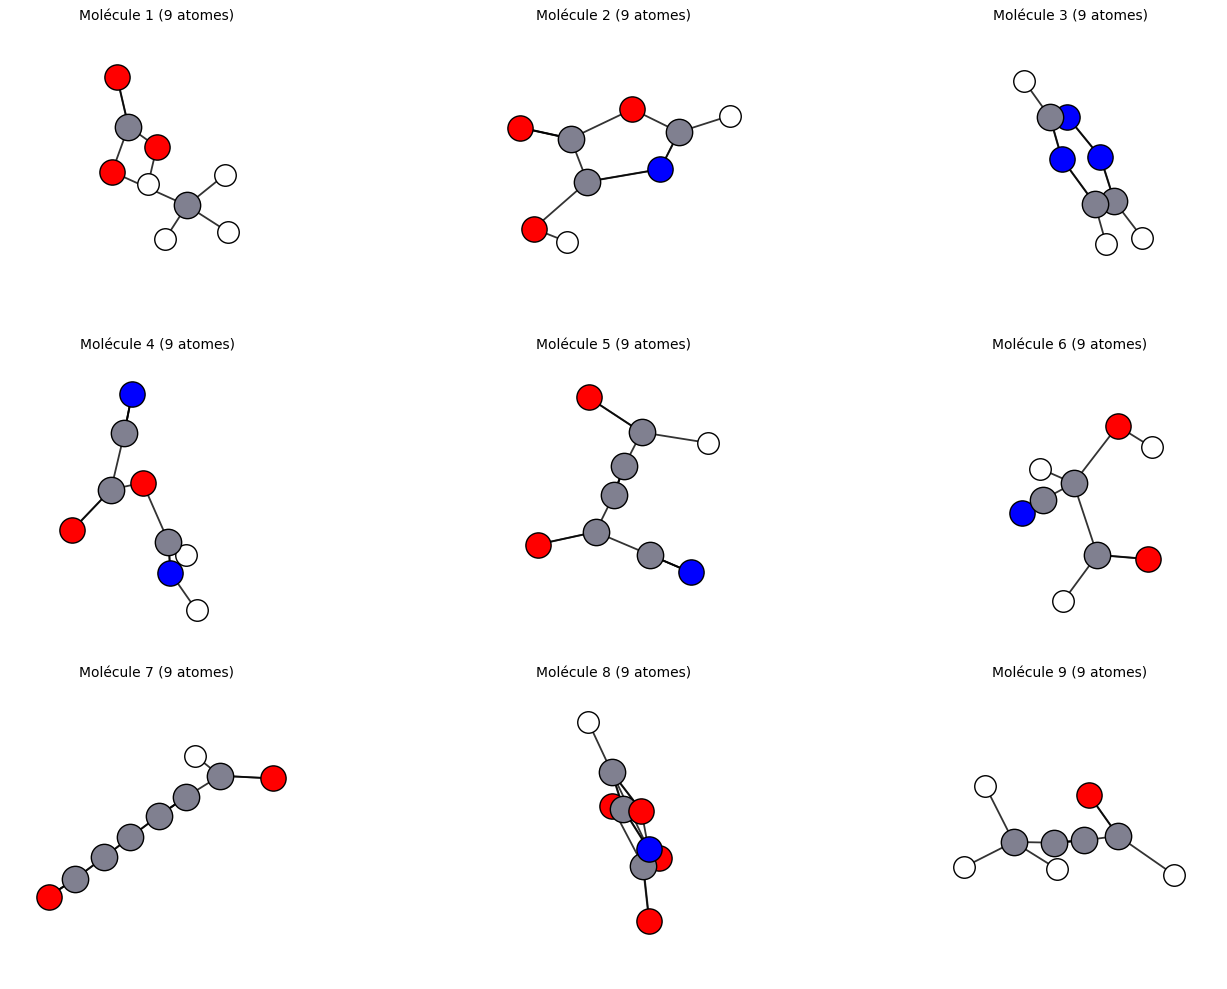

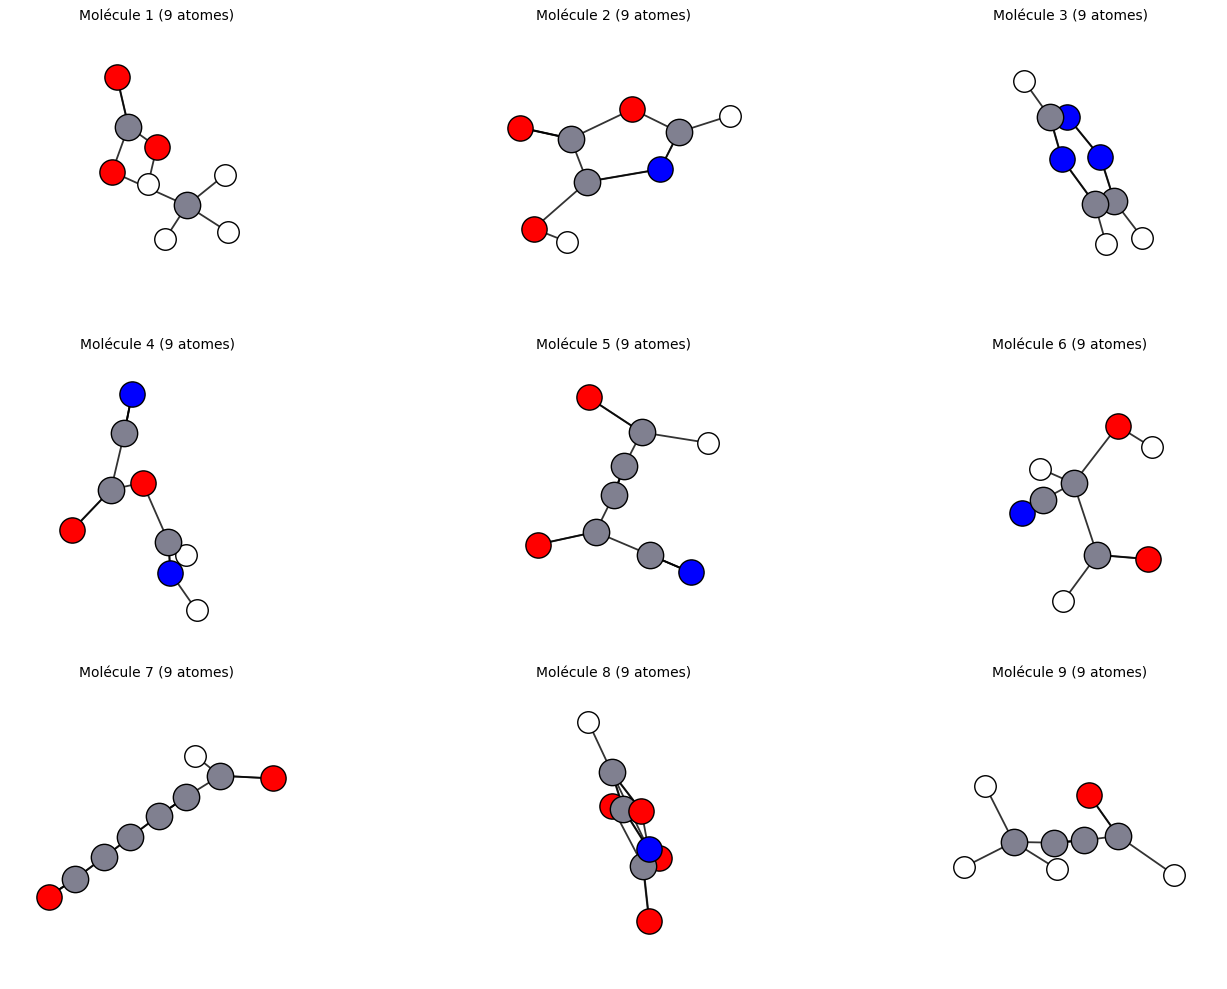

In [26]:
from display_mol import *

mols = [mol_to_dict([e[i] for e in mol]) for i in range(n)]

plot_multiple_molecules(mols, n_molecules=9)

1000it [00:35, 27.87it/s]


(<Figure size 1000x800 with 1 Axes>, <Axes3D: title={'center': 'Molécule'}>)

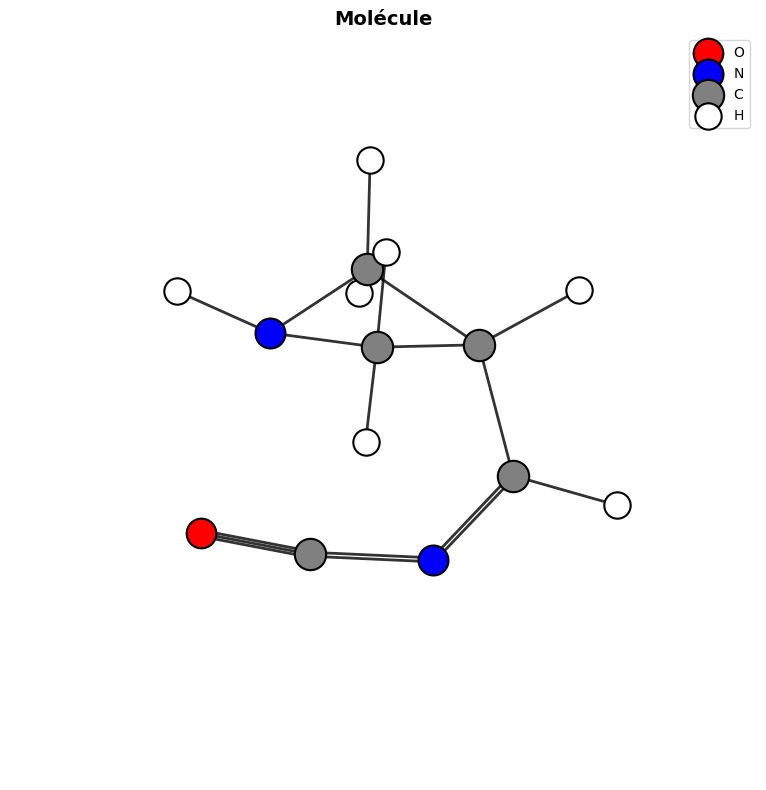

In [32]:

s = model.sample(1, 15)
mol = one_hot_decode(s)
b = mol_to_dict([e[0] for e in mol])

plot_molecule(b)